In [1]:
import torch
import torch.nn as nn
from config import TransformerConfig
from torch_optimizer import Yogi
from tqdm import tqdm
import matplotlib.pyplot as plt
from data import split_data, train_val_split, anomaly_detection_data_provider
import numpy as np
import os
import pandas as pd
from static import *
from sklearn.preprocessing import StandardScaler
from tfad.model.mixup import mixup_batch, slow_slope
from tfad.model.outlier_exposure import coe_batch
from utils import validate_tfad, tfad_search_best_threshold
from copy import deepcopy
from evaluate import calculate
from CATCH import CATCHModel
from torchinfo import summary

In [2]:
dataset_name = "NYC"
mode = "score"
config = TransformerConfig(
    Mlr=1e-05,
    batch_size=128,
    cf_dim=64,
    d_ff=256,
    d_model=256,
    e_layers=3,
    head_dim=64,
    inference_patch_size=32,
    inference_patch_stride=1,
    lr=0.0001,
    n_heads=2,
    num_epochs=2,
    patch_size=16, 
    patch_stride=8,
    seq_len=192,
    temperature=0.07,
    # TFAD
    hp_lamb = 6400,
    # hyper-parameter for TCN encoder
    embedding_rep_dim = 64,
    tcn_kernel_size = 3,
    tcn_out_channels = 64,
    tcn_layers = 3,
    tcn_maxpool_out_channels = 2,
    normalize_embedding = True,
    suspect_window_length = 12,
    # hyper-parameter for classifier
    distance = "L2",
    # TFAD training hyper-parameters
    num_epochs_tfad = 1,
    lr_tfad = 1e-5,
    coe_rate = 0.5,
    mixup_rate = 0.3,
    slow_slop = 0,
    # TFAD validation hyper-parameters
    classifier_threshold = 0.5,
    val_labels_adj = True,
    threshold_grid_length_val = 0.1,
    # TFAD test hyper-parameters
    test_labels_adj = True,
    threshold_grid_length_test = 0.01,
)
scaler = StandardScaler()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# load data
train_data, train_label, test_data, test_label = split_data(
    os.path.join("data",dataset_name+".csv"),TRAIN_LENGTH[dataset_name]
)
column_num = train_data.shape[1]
config.enc_in = column_num
config.dec_in = column_num
config.c_in = column_num
config.c_out = column_num
config.label_len = 48
model = CATCHModel(config)
state_dict = torch.load(dataset_name+".pth", weights_only=True)
model.load_state_dict(state_dict)
# fix random seed again
from data import fix_random_seed
fix_random_seed(2021)
model.to(device)
# 冻结CATCH模型参数
for name, param in model.named_parameters():
    if not name.startswith("TFAD"):
        param.requires_grad = False
# summary(model)

train_data_value, valid_data, train_label_value, valid_label = train_val_split(train_data, train_label, 0.8)
scaler.fit(train_data_value.values)
# data preprocess
train_data_value = pd.DataFrame(
    scaler.transform(train_data_value.values),
    columns=train_data_value.columns,
    index=train_data_value.index,
)
valid_data = pd.DataFrame(
    scaler.transform(valid_data.values),
    columns=valid_data.columns,
    index=valid_data.index,
)
test = pd.DataFrame(
    scaler.transform(test_data.values), columns=test_data.columns, index=test_data.index
)
actual_label = test_label.to_numpy().flatten()
valid_data_loader = anomaly_detection_data_provider(
    valid_data,
    valid_label,
    batch_size=config.batch_size,
    win_size=config.seq_len,
    step=1,
    mode="val",
)
train_data_loader = anomaly_detection_data_provider(
    train_data_value,
    train_label_value,
    batch_size=config.batch_size,
    win_size=config.seq_len,
    step=1,
    mode="train",
)

In [3]:
print("----------------------------TFAD TRAIN-----------------------")
tfad_params = model.TFAD.parameters()
optimizer_tfad = Yogi(tfad_params, lr=config.lr_tfad)
tfad_criterion = nn.BCEWithLogitsLoss()
# 使用 mode="tfad-val"确保shuffle=False保证窗口顺序
tfad_val_loader = anomaly_detection_data_provider(
    valid_data,
    valid_label,
    batch_size=config.batch_size,
    win_size=config.seq_len,
    step=1,
    mode="tfad", 
)
tfad_test_loader = anomaly_detection_data_provider(
    test,
    test_label,
    batch_size=config.batch_size,
    win_size=config.seq_len,
    step=1,
    mode="tfad", 
)
best_f1 = 0.0
train_loss_list = []
f1_list = []
for epoch in range(config.num_epochs_tfad):
    train_loss_tfad = []
    model.train()
    progress_bar = tqdm(train_data_loader, desc=f"Epoch {epoch+1}/{config.num_epochs_tfad}")
    for i, (input, target) in enumerate(progress_bar):
        optimizer_tfad.zero_grad()
        # 1. 准备原始正常数据
        # input: [bs, seq_len, n_vars]
        x = input.float().to(device).permute(0, 2, 1) # [bs, n_vars, seq_len]
        
        # TFAD 官方逻辑：只根据 suspect_window_length (窗口末尾) 来判断标签
        # target: [bs, seq_len, 1]
        y = target[:, -config.suspect_window_length:, :].squeeze(-1).max(dim=1)[0].float().to(device)

        # 2. 数据增强 (生成伪异常)
        # COE
        if config.coe_rate > 0:
            x_oe, y_oe = coe_batch(
                x=x,
                y=y,
                coe_rate=config.coe_rate,
                suspect_window_length=config.suspect_window_length,
                random_start_end=True,
            )
            x = torch.cat((x, x_oe), dim=0)
            y = torch.cat((y, y_oe), dim=0)

        # Mixup
        if config.mixup_rate > 0.0:
            x_mixup, y_mixup = mixup_batch(
                x=x,
                y=y,
                mixup_rate=config.mixup_rate,
            )
            x = torch.cat((x, x_mixup), dim=0)
            y = torch.cat((y, y_mixup), dim=0)
            
        # Slow Slop
        if config.slow_slop > 0.0:
            x_slow, y_slow = slow_slope(
                x=x,
                y=y,
                mixup_rate=config.slow_slop,
            )
            x = torch.cat((x, x_slow), dim=0)
            y = torch.cat((y, y_slow), dim=0)
        
        # 3. 前向传播与 Loss 计算
        # 统一为[bs, seq_len, n_vars]形式输入
        logits_anomaly = model(x.permute(0, 2, 1), mode="TFAD")["TFAD_score"].squeeze()
        loss = tfad_criterion(logits_anomaly, y)
        
        loss.backward()
        optimizer_tfad.step()
        train_loss_tfad.append(loss.item())
        
        if (i + 1) % 100 == 0:
            print(f"Epoch: {epoch+1}, Iter: {i+1}, TFAD Loss: {np.mean(train_loss_tfad):.7f}")

    print(f"Train Loss: {np.mean(train_loss_tfad):.7f}")
    train_loss_list.append(np.mean(train_loss_tfad))
    # TFAD Validation
    tfad_labels = valid_label.to_numpy().astype(float).flatten()
    if sum(tfad_labels) == 0:
        if epoch == 0:
            print("Warning: No anomaly in validation set, use test set instead")
        tfad_probs = validate_tfad(model, tfad_test_loader, config, device)
        tfad_labels = test_label.to_numpy().astype(float).flatten()
    else:
        tfad_probs = validate_tfad(model, tfad_val_loader, config, device)
    metrics_best, threshold_best = tfad_search_best_threshold(tfad_probs, tfad_labels, config, stage="val")
    config.classifier_threshold = threshold_best
    print(f"Best threshold: {threshold_best:.4f}")
    print(f"Metrics: {metrics_best}")
    f1_list.append(metrics_best["f1"])
    if metrics_best["f1"] > best_f1:
        best_f1 = metrics_best["f1"]
        checkpoint = deepcopy(model.state_dict())

----------------------------TFAD TRAIN-----------------------


Epoch 1/30: 100%|██████████████████████████████████████████████████████████████████████| 15/15 [00:02<00:00,  5.25it/s]


Train Loss: 1.3238065
Best threshold: 0.1000
Metrics: {'f1': 0.3025830258302583, 'f2': 0.42619542619542616, 'f0.5': 0.23455377574370706, 'precision': 0.20398009950248755, 'recall': 0.5857142857142857, 'TN': 2110, 'FN': 29, 'TP': 41, 'FP': 160}


Epoch 2/30: 100%|██████████████████████████████████████████████████████████████████████| 15/15 [00:02<00:00,  7.03it/s]


Train Loss: 1.2940824
Best threshold: 0.1000
Metrics: {'f1': 0.2887323943661972, 'f2': 0.4149797570850202, 'f0.5': 0.22138228941684665, 'precision': 0.19158878504672897, 'recall': 0.5857142857142857, 'TN': 2097, 'FN': 29, 'TP': 41, 'FP': 173}


...

Train Loss: 0.9583363
Best threshold: 0.3000
Metrics: {'f1': 0.28378378378378377, 'f2': 0.2932960893854748, 'f0.5': 0.27486910994764396, 'precision': 0.2692307692307692, 'recall': 0.3, 'TN': 2213, 'FN': 49, 'TP': 21, 'FP': 57}


Epoch 29/30: 100%|█████████████████████████████████████████████████████████████████████| 15/15 [00:02<00:00,  7.07it/s]


Train Loss: 0.9712620
Best threshold: 0.3000
Metrics: {'f1': 0.2608695652173913, 'f2': 0.2830188679245283, 'f0.5': 0.24193548387096778, 'precision': 0.23076923076923078, 'recall': 0.3, 'TN': 2200, 'FN': 49, 'TP': 21, 'FP': 70}


Epoch 30/30: 100%|█████████████████████████████████████████████████████████████████████| 15/15 [00:02<00:00,  7.21it/s]


Train Loss: 0.9501898
Best threshold: 0.3000
Metrics: {'f1': 0.23863636363636365, 'f2': 0.27202072538860106, 'f0.5': 0.21255060728744943, 'precision': 0.19811320754716982, 'recall': 0.3, 'TN': 2185, 'FN': 49, 'TP': 21, 'FP': 85}


----------------------------TFAD TEST-----------------------
Best threshold: 0.2000
Metrics: {'f1': 0.31578947368421056, 'f2': 0.46692607003891046, 'f0.5': 0.23856858846918486, 'precision': 0.20512820512820512, 'recall': 0.6857142857142857, 'TN': 2084, 'FN': 22, 'TP': 48, 'FP': 186}
---------------------------UNION TEST-----------------------
{'auc_roc': 0.8431774988398046, 'auc_pr': 0.1233639540318322, 'R_AUC_ROC': 0.863446755579404, 'R_AUC_PR': 0.15377722302219754, 'VUS_ROC': 0.8563498780808, 'VUS_PR': 0.15118259961531166}
Best threshold: 0.7300
Metrics: {'f1': 0.3411764705882353, 'f2': 0.36989795918367346, 'f0.5': 0.3165938864628821, 'precision': 0.3020833333333333, 'recall': 0.3918918918918919, 'TN': 2379, 'FN': 45, 'TP': 29, 'FP': 67}


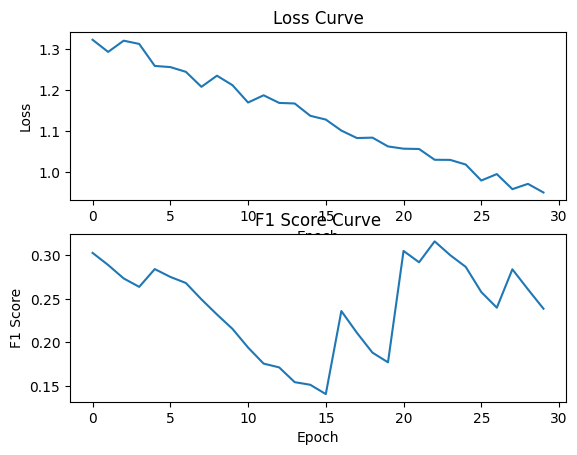

In [4]:
print("----------------------------TFAD TEST-----------------------")
model.load_state_dict(checkpoint)
model.to(device)
model.eval()
tfad_labels = test_label.to_numpy().astype(float).flatten()
tfad_probs = validate_tfad(model, tfad_test_loader, config, device)
metrics_best, threshold_best = tfad_search_best_threshold(tfad_probs, tfad_labels, config, stage="test")
print(f"Best threshold: {threshold_best:.4f}")
print(f"Metrics: {metrics_best}")
print("---------------------------UNION TEST-----------------------")
scores = np.load(dataset_name+".npy")
scores_min = np.min(scores)
scores_max = np.max(scores)
scores_normalized = (scores - scores_min) / (scores_max - scores_min)
probs_min = np.nanmin(tfad_probs)
probs_max = np.nanmax(tfad_probs)
tfad_probs_normalized = (tfad_probs - probs_min) / (probs_max - probs_min)
tfad_probs_normalized = np.nan_to_num(tfad_probs_normalized, nan=0.0)
final_scores = np.maximum(scores_normalized, tfad_probs_normalized)
results = calculate(mode, actual_label.astype(float), predicted=final_scores.astype(float))
print(results)
metrics_best, threshold_best = tfad_search_best_threshold(final_scores, actual_label, config, stage="test")
print(f"Best threshold: {threshold_best:.4f}")
print(f"Metrics: {metrics_best}")
plt.subplot(2,1,1)
plt.plot(train_loss_list)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.subplot(2,1,2)
plt.plot(f1_list)
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("F1 Score Curve")
plt.show()